In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split


In [10]:
# Paths
IMAGE_DIR = "/home/ujjwal-hirwani/Projects/DL_Projects/Brain Tumor Detection/dataset/images"
MASK_DIR = "/home/ujjwal-hirwani/Projects/DL_Projects/Brain Tumor Detection/dataset/masks"

# Hyperparameters
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 40
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cuda


In [11]:
class BrainTumorDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, IMG_SIZE)
        mask = cv2.resize(mask, IMG_SIZE)

        image = image / 255.0
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        if self.transform:
            image = self.transform(image)

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).permute(2, 0, 1)

        return image, mask


In [12]:
# List all images
all_images = sorted(os.listdir(IMAGE_DIR))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

# Create subsets
train_dataset = BrainTumorDataset(IMAGE_DIR, MASK_DIR)
val_dataset = BrainTumorDataset(IMAGE_DIR, MASK_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        output = self.final(c8)
        return output


In [14]:
def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    num = 2 * (pred * target).sum() + smooth
    den = pred.sum() + target.sum() + smooth
    return 1 - num / den


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        dice = dice_loss(pred, target)
        return 0.5 * bce + 0.5 * dice


In [15]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(loader):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            total_loss += loss.item()

    return total_loss / len(loader)


In [8]:
model = UNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = BCEDiceLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val = float('inf')
patience, counter = 7, 0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_loss = validate(model, val_loader, loss_fn)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "unet_best_pytorch.pth")
        counter = 0
        print("✅ Model Saved!")
    else:
        counter += 1
        if counter >= patience:
            print("⏹ Early stopping triggered!")
            break



Epoch [1/40]


100%|██████████| 383/383 [02:49<00:00,  2.26it/s]


Train Loss: 0.6139 | Val Loss: 0.5496
✅ Model Saved!

Epoch [2/40]


100%|██████████| 383/383 [02:45<00:00,  2.32it/s]


Train Loss: 0.5054 | Val Loss: 0.4645
✅ Model Saved!

Epoch [3/40]


...

Train Loss: 0.0437 | Val Loss: 0.0413
✅ Model Saved!

Epoch [39/40]


100%|██████████| 383/383 [02:45<00:00,  2.31it/s]


Train Loss: 0.0411 | Val Loss: 0.0395
✅ Model Saved!

Epoch [40/40]


100%|██████████| 383/383 [02:48<00:00,  2.28it/s]


Train Loss: 0.0386 | Val Loss: 0.0380
✅ Model Saved!


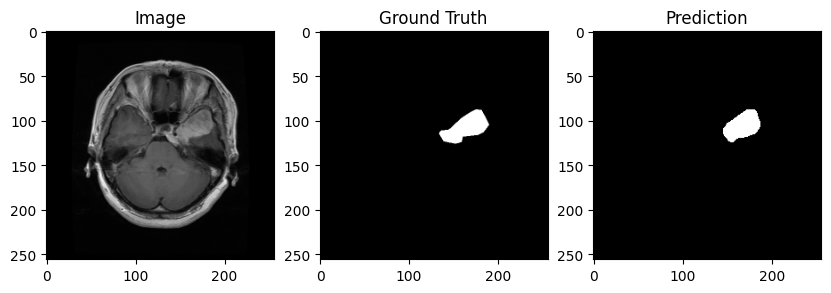

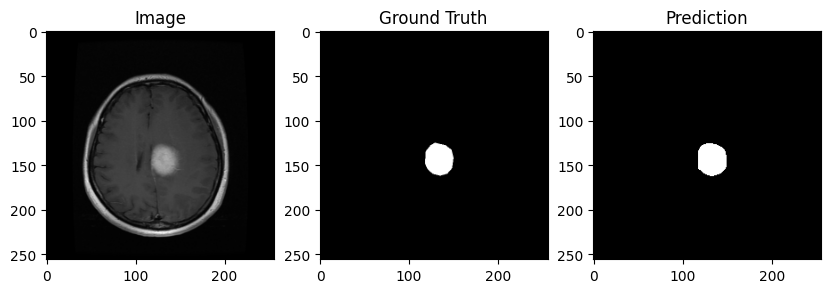

In [16]:
model.load_state_dict(torch.load("unet_best_pytorch.pth"))
model.eval()

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

        for i in range(2):
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 3, 1)
            plt.imshow(np.transpose(imgs[i].cpu().numpy(), (1, 2, 0)))
            plt.title("Image")

            plt.subplot(1, 3, 2)
            plt.imshow(masks[i].cpu().numpy().squeeze(), cmap="gray")
            plt.title("Ground Truth")

            plt.subplot(1, 3, 3)
            plt.imshow(preds[i].cpu().numpy().squeeze(), cmap="gray")
            plt.title("Prediction")
            plt.show()
        break


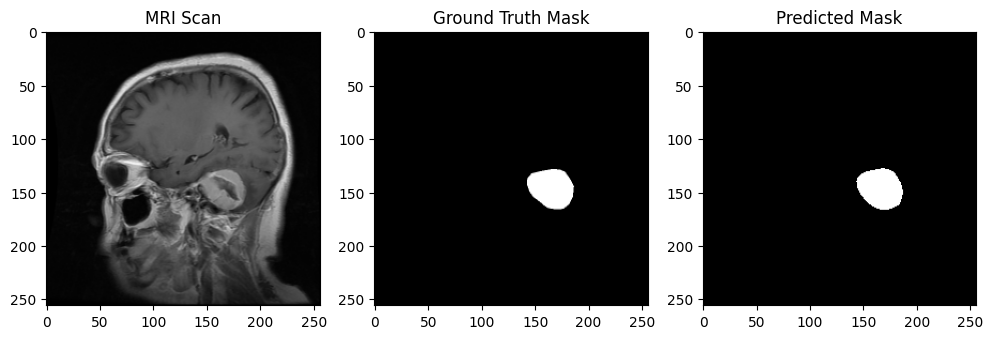

In [18]:
import torch
import matplotlib.pyplot as plt
import random
import numpy as np

# Ensure model is in evaluation mode
model.eval()

# Pick a random index from the validation dataset
random_idx = random.randint(0, len(val_loader.dataset) - 1)

# Get the image and mask at that index
img, mask = val_loader.dataset[random_idx]

# Add batch dimension and move to device
img_batch = img.unsqueeze(0).to(DEVICE)

# Make prediction
with torch.no_grad():
    pred = torch.sigmoid(model(img_batch))
    pred = (pred > 0.5).float()  # Binary mask

# Convert tensors to numpy for visualization
img_np = np.transpose(img.cpu().numpy(), (1, 2, 0))
mask_np = mask.cpu().numpy().squeeze()
pred_np = pred.cpu().numpy().squeeze()

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("MRI Scan")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(pred_np, cmap="gray")
plt.title("Predicted Mask")

plt.show()


Input shape: torch.Size([1, 3, 256, 256])


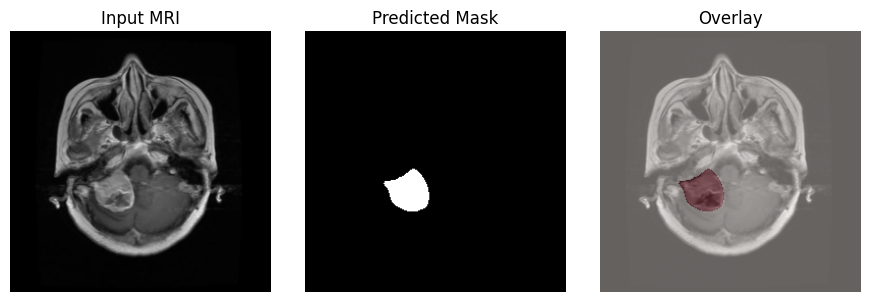

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# CONFIG
# -----------------------------
IMAGE_PATH = "/home/ujjwal-hirwani/Projects/DL_Projects/Brain Tumor Detection/archive/Training/meningioma/Tr-me_0020.jpg"
IMG_SIZE = 256
THRESHOLD = 0.5

# -----------------------------
# TRANSFORM (3-channel)
# -----------------------------
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # produces [3, H, W] for RGB
])

# -----------------------------
# LOAD IMAGE AS RGB (IMPORTANT)
# -----------------------------
img = Image.open(IMAGE_PATH).convert("RGB")  
img_tensor = test_transform(img)

# Add batch dimension
img_batch = img_tensor.unsqueeze(0).to(DEVICE)  # [1, 3, H, W]

print("Input shape:", img_batch.shape)

# -----------------------------
# MODEL INFERENCE
# -----------------------------
model.eval()
with torch.no_grad():
    pred = torch.sigmoid(model(img_batch))
    pred = (pred > THRESHOLD).float()

# -----------------------------
# CONVERT TO NUMPY
# -----------------------------
img_np = np.transpose(img_tensor.cpu().numpy(), (1, 2, 0))
pred_np = pred.cpu().numpy().squeeze()

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_np, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(pred_np, cmap="Reds", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


In [24]:
import torch

model.eval()
model.cpu()   # 👈 move model to CPU

example_input = torch.randn(1, 3, 256, 256)  # CPU tensor

scripted_model = torch.jit.trace(model, example_input)
scripted_model.save("segmentation_model_torchscript.pt")

print("TorchScript model saved successfully")


TorchScript model saved successfully


In [25]:
with torch.no_grad():
    original_out = model(example_input)
    scripted_out = scripted_model(example_input)

print(torch.mean(torch.abs(original_out - scripted_out)))


tensor(0.)
